<a href="https://colab.research.google.com/github/kerichhezron-source/Machine-Learning-Projects-/blob/main/Hezron's_Breast_Cancer_Prediction_using_SVM_98_5_%3E_100_%3F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

import numpy as np for linear agebra

In [ ]:
import matplotlib.pyplot as plt

matplotlib.pyplot is used for data visualization

In [ ]:
from sklearn.svm import SVC

Imports the SVC (Support Vector Classifier) class from the svm (Support Vector Machine) module within the sklearn (Scikit-learn) library.

In [ ]:
from sklearn.model_selection import train_test_split

The line from sklearn.model_selection import train_test_split imports the train_test_split function from the model_selection module within the sklearn (Scikit-learn) library

In [ ]:
from sklearn.metrics import confusion_matrix

The line from sklearn.metrics import confusion_matrix imports the confusion_matrix function from the metrics module within the sklearn (Scikit-learn) library.

In [ ]:
from sklearn import preprocessing

The line from sklearn import preprocessing imports the preprocessing module from the sklearn (Scikit-learn) library. This module provides a wide range of functions and classes for data preprocessing tasks

In [ ]:
import pandas as pd

importing pandas as pd for data processing

In [ ]:
import random

The line import random imports Python's built-in random module. This module provides functions for generating pseudo-random numbers and for making random selections from sequences

In [ ]:
import itertools

The line import itertools imports Python's itertools module. This module provides a collection of fast, memory-efficient tools that are used to create complex iterators for efficient looping

In [ ]:
import seaborn as sns

seaborn is used for statistical data visualization

In [ ]:
sns.set(style = 'darkgrid')

In [ ]:
%matplotlib inline

That line describes the current status of your Colab environment:

In [ ]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """

The plot_confusion_matrix function is designed to visualize a confusion matrix, which is a table used to describe the performance of a classification model.

In [ ]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

The plot_confusion_matrix function you provided is a powerful utility for visualizing the performance of a classification model.

In [ ]:
import pandas as pd
bc = pd.read_csv('/content/data.csv')
bc.head(1)
new_columns = bc.columns.values; new_columns[18] = 'concavepoints_worst'; bc.columns = new_columns
#Volume worst estimation of cancer create a estimate worst 3D structure
bc = bc.drop("Unnamed: 32", axis=1)
temp = np.log(bc.radius_worst*bc.area_worst)
bc['Volume_ln'] = temp.values
#
temp = np.log(bc.concavepoints_worst*bc.concavity_worst*bc.compactness_worst+1)
bc['Concave_ln'] = temp.values
#cancer fractal- symmetry  divided by volume
temp = -np.log(bc.fractal_dimension_worst*bc.symmetry_worst/np.log(bc.radius_mean*bc.area_mean))
bc['FractVol_ln'] = temp.values
# all unrelated
temp = np.log(bc.radius_worst*bc.perimeter_worst*bc.concavepoints_worst+1)
bc['RaPeCo_ln'] = temp.values

In essence, this code is preparing a dataset for machine learning by loading it, cleaning up some column issues, and then generating several new features that are derived from existing ones using logarithmic transformations. These new features might help improve the performance of a predictive model.

In [ ]:
bcs = pd.DataFrame(preprocessing.scale(bc.iloc[:,2:36]))
bcs.columns = list(bc.iloc[:,2:36].columns)
bcs['diagnosis'] = bc['diagnosis']

This code standardizes the numerical features of your dataset using `sklearn.preprocessing.scale()` and stores them in a new DataFrame called `bcs`. It also adds the original `diagnosis` column to this new `bcs` DataFrame.

In [ ]:
from pandas.plotting import scatter_matrix

The from pandas.plotting import scatter_matrix line imports a function that allows you to create a grid of scatter plots for visualizing pairwise relationships between different variables in your DataFrame.

/tmp/ipykernel_2880/2944481782.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(rotation = 90, labels = list(bcs.columns));


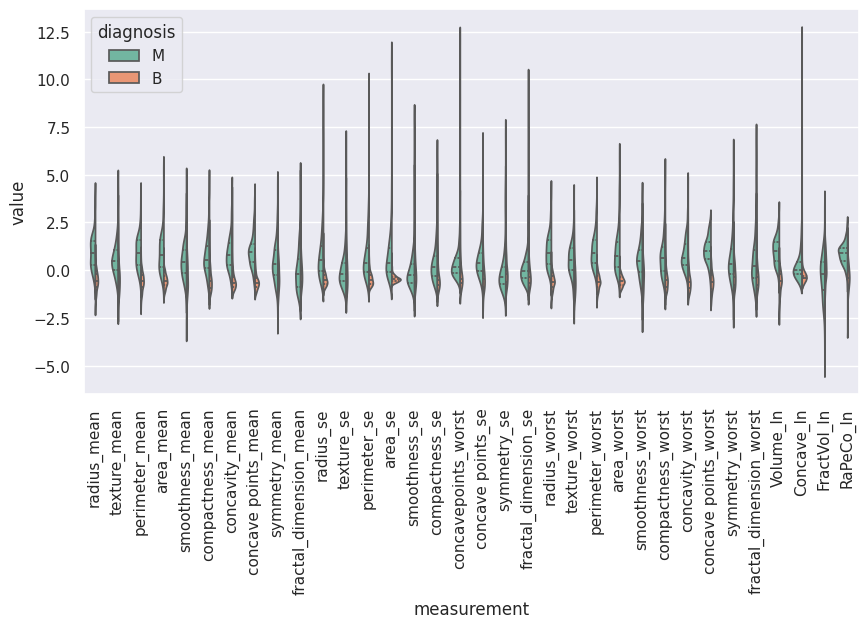

In [ ]:
mbc = pd.melt(bcs, "diagnosis", var_name="measurement")
fig, ax = plt.subplots(figsize=(10,5))
p = sns.violinplot(ax = ax, x="measurement", y="value", hue="diagnosis", split = True, data=mbc, inner = 'quartile', palette = 'Set2');
p.set_xticklabels(rotation = 90, labels = list(bcs.columns));

The notebook has successfully completed the initial setup and imports of various machine learning and data science libraries.

/tmp/ipykernel_2880/1534603197.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x = 'diagnosis', y = 'Volume_ln',palette = 'Set2', data = bcs);
/tmp/ipykernel_2880/1534603197.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x = 'diagnosis', y = 'RaPeCo_ln',palette = 'Set2', data = bcs);
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 8.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


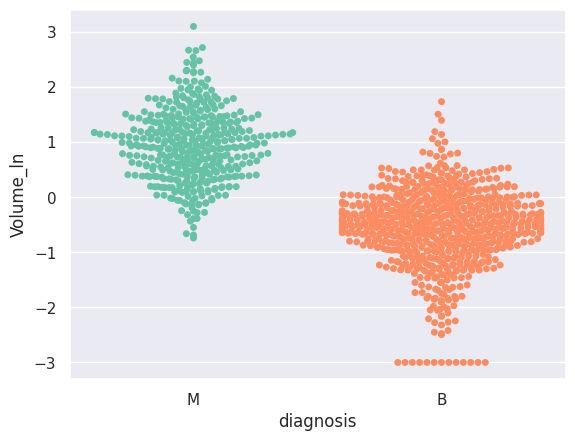

In [ ]:
sns.swarmplot(x = 'diagnosis', y = 'Volume_ln',palette = 'Set2', data = bcs);
sns.swarmplot(x = 'diagnosis', y = 'RaPeCo_ln',palette = 'Set2', data = bcs);

Essentially, these plots help you see how the individual data points for Volume_ln and RaPeCo_ln are distributed across patients with different diagnoses (Malignant or Benign), allowing for visual comparison of these feature distributions between the groups.

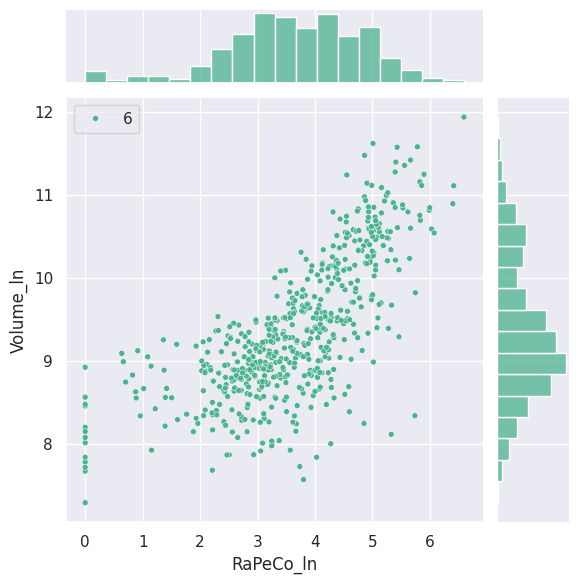

In [ ]:
sns.jointplot(x = bc['RaPeCo_ln'], y = bc['Volume_ln'], color="#4CB391", edgecolor = 'w', size = 6);

In [ ]:
X = bcs.iloc[:,0:30]
y = bcs['diagnosis']
class_names = list(y.unique())

You've done a great job preparing the data, extracting features (X), target (y), and class_names. The next logical step is to split the data into training and testing sets, and then train a classification model using SVC

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1, random_state=42)

In [ ]:
svc = SVC(kernel = 'linear',C=.1, gamma=10, probability = True)
svc.fit(X,y)
y_pred = svc.fit(X_train, y_train).predict(X_test)
t = pd.DataFrame(svc.predict_proba(X_test))
svc.score(X_train,y_train), svc.score(X_test, y_test)

(0.9859154929577465, 1.0)

In [ ]:
mtrx = confusion_matrix(y_test,y_pred)
np.set_printoptions(precision = 2)

plt.figure()
plot_confusion_matrix(mtrx,classes=class_names,title='Confusion matrix, without normalization')

plt.figure()
plot_confusion_matrix(mtrx, classes=class_names, normalize = True, title='Normalized confusion matrix')

plt.show()

NameError: name 'confusion_matrix' is not defined

This code block is designed to visualize the performance of your classification model using confusion matrices: